## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [39]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [40]:
print(y_train.shape, y_test.shape)

(60000,) (10000,)


In [41]:
y_train[0:5]

array([9, 0, 0, 3, 0], dtype=uint8)

### Find dimensions of an image in the dataset

In [42]:
x_train[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import tensorflow as tf

In [0]:
y_train_hot = tf.keras.utils.to_categorical(y_train)
y_test_hot = tf.keras.utils.to_categorical(y_test)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train_norm = x_train/255

In [0]:
x_test_norm = x_test/255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [47]:
x_train_norm.shape

(60000, 28, 28)

In [0]:
x_train_norm = x_train_norm.reshape(-1,28,28,1)
x_test_norm = x_test_norm.reshape(-1,28,28,1)

In [49]:
x_train_norm.shape

(60000, 28, 28, 1)

### Import the necessary layers from keras to build the model

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [50]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), input_shape=(28,28,1,), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cbks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(x_train_norm, y_train_hot,
                    validation_data=(x_test_norm, y_test_hot),
                    batch_size=32,
                    epochs=10, callbacks=[cbks])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 139us/sample - loss: 0.3750 - acc: 0.8652 - val_loss: 0.2878 - val_acc: 0.8948
Epoch 2/10
60000/60000 [==============================] - 8s 135us/sample - loss: 0.2322 - acc: 0.9143 - val_loss: 0.2676 - val_acc: 0.9045
Epoch 3/10
60000/60000 [==============================] - 8s 132us/sample - loss: 0.1713 - acc: 0.9366 - val_loss: 0.2328 - val_acc: 0.9181
Epoch 4/10
60000/60000 [==============================] - 8s 132us/sample - loss: 0.1210 - acc: 0.9550 - val_loss: 0.2666 - val_acc: 0.9140
Epoch 5/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.0842 - acc: 0.9687 - val_loss: 0.2922 - val_acc: 0.9155
Epoch 6/10
60000/60000 [==============================] - 8s 132us/sample - loss: 0.0558 - acc: 0.9795 - val_loss: 0.3484 - val_acc: 0.9153
Epoch 7/10
60000/60000 [==============================] - 8s 132us/sample - loss: 0.0390 - acc: 0.9861 - val_l

In [51]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 24, 24, 32)        9248      
_________________________________________________________________
flatten_6 (Flatten)          (None, 18432)             0         
_________________________________________________________________
dense_12 (Dense)             (None, 128)               2359424   
_________________________________________________________________
dense_13 (Dense)             (None, 10)                1290      
Total params: 2,370,282
Trainable params: 2,370,282
Non-trainable params: 0
_________________________________________________________________


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [52]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), input_shape=(28,28,1,), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cbks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(x_train_norm, y_train_hot,
                    validation_data=(x_test_norm, y_test_hot),
                    batch_size=32,
                    epochs=10, callbacks=[cbks])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 132us/sample - loss: 0.3937 - acc: 0.8581 - val_loss: 0.2970 - val_acc: 0.8919
Epoch 2/10
60000/60000 [==============================] - 7s 123us/sample - loss: 0.2587 - acc: 0.9052 - val_loss: 0.2626 - val_acc: 0.9073
Epoch 3/10
60000/60000 [==============================] - 8s 126us/sample - loss: 0.2115 - acc: 0.9208 - val_loss: 0.2362 - val_acc: 0.9158
Epoch 4/10
60000/60000 [==============================] - 7s 124us/sample - loss: 0.1755 - acc: 0.9336 - val_loss: 0.2207 - val_acc: 0.9183
Epoch 5/10
60000/60000 [==============================] - 8s 131us/sample - loss: 0.1485 - acc: 0.9445 - val_loss: 0.2256 - val_acc: 0.9184
Epoch 6/10
60000/60000 [==============================] - 7s 124us/sample - loss: 0.1252 - acc: 0.9524 - val_loss: 0.2292 - val_acc: 0.9219
Epoch 7/10
60000/60000 [==============================] - 8s 126us/sample - loss: 0.1030 - acc: 0.9614 - val_l

In [53]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_14 (Conv2D)           (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_15 (Conv2D)           (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 12, 12, 32)        0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 12, 12, 32)        0         
_________________________________________________________________
flatten_7 (Flatten)          (None, 4608)              0         
_________________________________________________________________
dense_14 (Dense)             (None, 128)               589952    
_________________________________________________________________
dense_15 (Dense)             (None, 10)               

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)
datagen.fit(x_train_norm)


#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

In [55]:
x_train.shape

(60000, 28, 28)

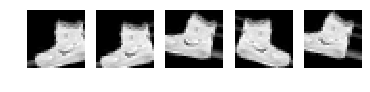

In [56]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train_norm[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [57]:
cbks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit_generator(datagen.flow(x_train_norm, y_train_hot, batch_size=32), 
                    validation_data=datagen.flow(x_test_norm, y_test_hot, batch_size=32),
                    steps_per_epoch=len(x_train) / 32, epochs=10, callbacks=[cbks])


Epoch 1/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.9373 - acc: 0.6840 - val_loss: 0.6617 - val_acc: 0.7629
Epoch 2/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.6265 - acc: 0.7688 - val_loss: 0.5874 - val_acc: 0.7801
Epoch 3/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.5606 - acc: 0.7926 - val_loss: 0.5178 - val_acc: 0.8125
Epoch 4/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.5240 - acc: 0.8065 - val_loss: 0.4899 - val_acc: 0.8200
Epoch 5/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4904 - acc: 0.8196 - val_loss: 0.4650 - val_acc: 0.8277
Epoch 6/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4733 - acc: 0.8255 - val_loss: 0.4398 - val_acc: 0.8372
Epoch 7/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4540 - acc: 0.8314 - val_loss: 0.4359 - val_acc: 0.8400
Epoch 8/10
1875/1875 [==========================

###  Report the final train and validation accuracy

In [58]:
print(history.history.keys())

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


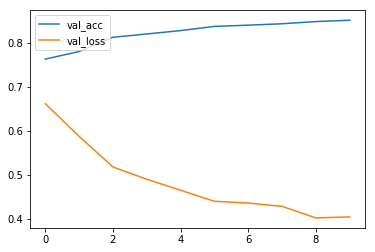

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_acc'])
plt.plot(history.history['val_loss'])
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()


In [60]:
print("Final train accuracy", history.history["acc"][-1])
print("Final test accuracy", history.history["val_acc"][-1])

Final train accuracy 0.8422167
Final test accuracy 0.8512


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

### **Load CIFAR10 dataset**

In [0]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [0]:
y_train_hot = tf.keras.utils.to_categorical(y_train)
y_test_hot = tf.keras.utils.to_categorical(y_test)

In [0]:
x_train_norm = x_train/255
x_test_norm = x_test/255

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
    )
datagen.fit(x_train_norm)


### **Prepare/fit the generator.**

In [0]:
datagen.fit(x_train_norm)


**Generate 5 images for 1 of the image of CIFAR10 train dataset.**

W0818 10:24:50.689615 140375617836928 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:24:50.703549 140375617836928 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:24:50.715186 140375617836928 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:24:50.728507 140375617836928 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:24:50.741810 140375617836928 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


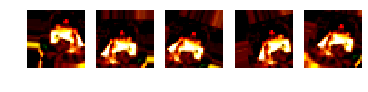

In [70]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train_norm[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()